# test workflow

In [23]:
import pandas as pd
import torch

In [24]:
dataset_path = "./dataset/ptb_xl_test/"

database = pd.read_csv(dataset_path + "ptbxl_database.csv")
statements = pd.read_csv(dataset_path + "scp_statements.csv")
print(f"Dataset: {database.shape}\nStatements: {statements.shape}")

Dataset: (999, 28)
Statements: (71, 13)


In [25]:
database.head(2)

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


In [66]:
import pandas as pd
import numpy as np
import wfdb
import ast
from sklearn.preprocessing import MultiLabelBinarizer

sampling_rate = 100
path = dataset_path
targer = 'scp'
mode='train'

test_fold = 10
val_fold = 9



# # load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)

if mode == 'train':
    Y = Y[~Y.strat_fold.isin([test_fold, val_fold])]
elif mode == 'val':
    Y = Y[Y.strat_fold == val_fold]
elif mode == 'test':
    Y = Y[Y.strat_fold == test_fold]
else:
    raise ValueError('Invalid mode (train|val|test)')

Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# # Load raw signal data
if sampling_rate == 100:
    data = [wfdb.rdsamp(path+f) for f in Y.filename_lr]
else:
    data = [wfdb.rdsamp(path+f) for f in Y.filename_hr]
X = np.array([signal for signal, meta in data])

# Load scp_statements.csv for diagnostic aggregation
agg_df = agg_df[agg_df.diagnostic == 1]

name_to_index = {v:i for i,v in enumerate(agg_df.diagnostic_class.unique())}
labels = []
for codes in Y.scp_codes:
    tmp = []
    for key, value in codes.items():
        if (key in agg_df.index) and (value > 0.5):
            tmp.append(name_to_index[agg_df.loc[key].diagnostic_class])
    labels.append(tmp)

# transform labels to ONEHOT (doing classification)
y = MultiLabelBinarizer().fit_transform(labels)


In [67]:
print(X.shape)
print(y.shape)

(732, 1000, 12)
(732, 5)


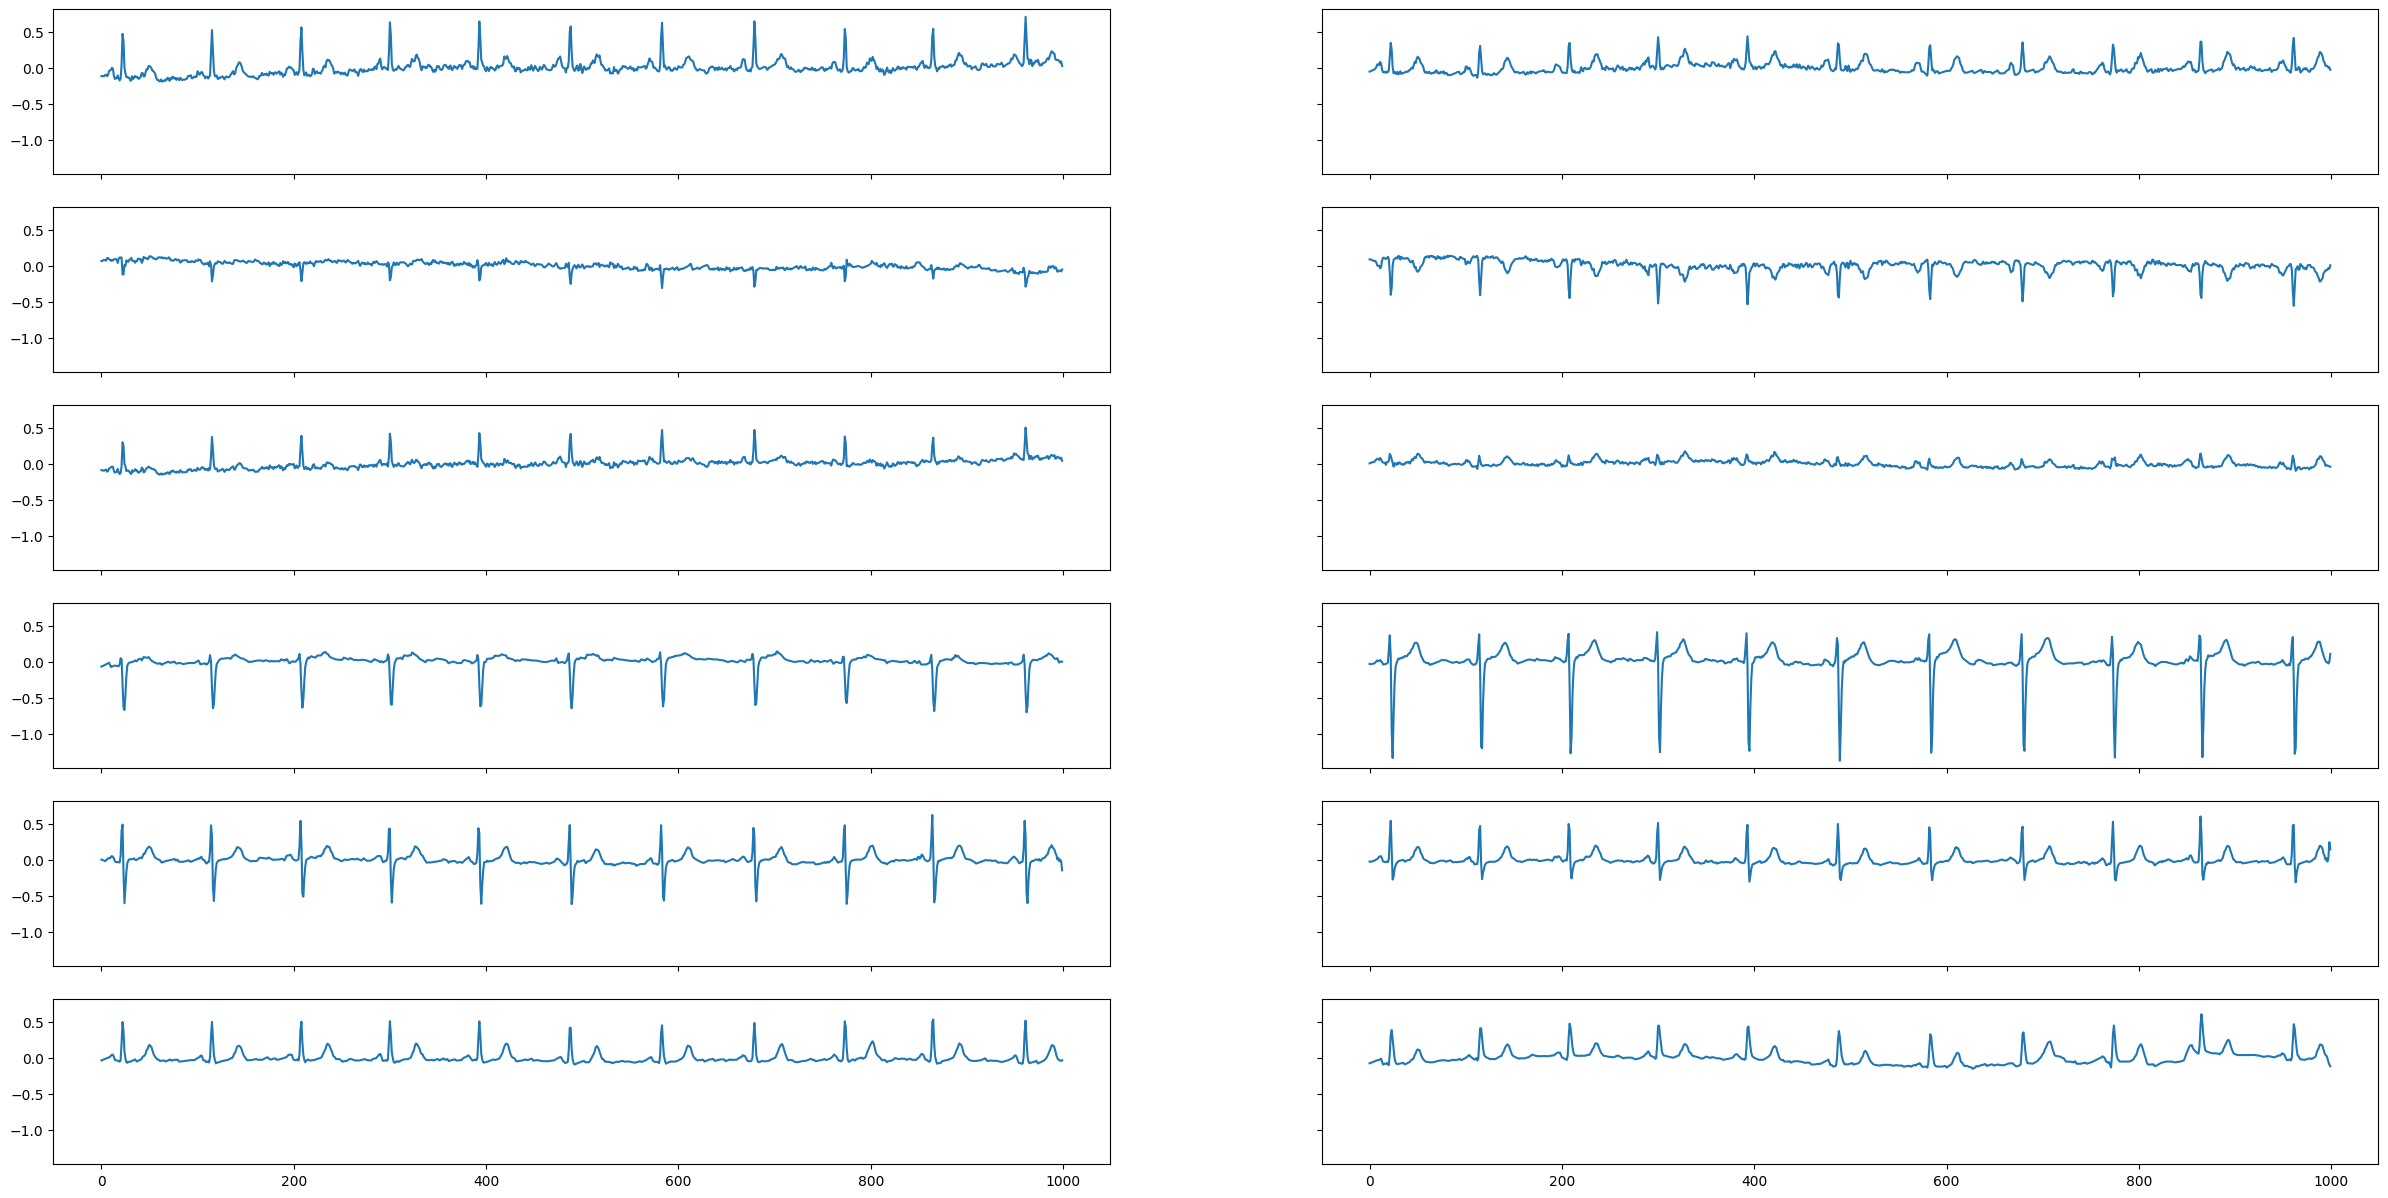

In [34]:
import matplotlib.pyplot as plt
sample = X_train[0]
fig, axs = plt.subplots(6, 2, figsize=(30, 15), sharex=True, sharey=True)
for i,ax in enumerate(axs.flat):
    ax.plot(sample[:,i])